# Demo SuStaIn

Aquesta _Jupyter Notebook_  serveix per mostrar de manera còmoda el funcionament de l'algorisme dels models de progressió de la malaltia.

Per a fer més senzilla l'execució s'utilitzarà un model amb 2 subtipus amb la base del model de 4 biomarcadors.

## IMPORTS

In [26]:
import os
import pandas 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pySuStaIn
import statsmodels.formula.api as smf
from scipy import stats
import sklearn.model_selection
from sklearn.preprocessing import LabelEncoder
import math

## PREPARACIÓ DEL DATASET

In [27]:
# Load the data 
# The data needs to be in the same directory as your notebook

# Obrir els dataframes i combinar-los
df1 = pandas.read_csv('info_subjecte.csv', sep = ',')
df2 = pandas.read_csv('A4_synthseg_vols.csv', sep = ',')
df3 = pandas.read_csv('info_PET.csv', sep = ',')
df4 = pandas.read_csv('info_TAU.csv', sep=',')

# Ens quedarem amb només una run per pacient, no volem pacients repetits
df2 = df2[df2['Unnamed: 0'] == 0]

df12 = pandas.merge(df1, df2, left_on='BID', right_on='subject')
# Al segmentar amb NextBrain dos pacients no es van fer, per consistència els eliminem tot i treballar amb Synthseg
ids_to_remove = {'B69162123', 'B11343379'}
df12 = df12[~df12['subject'].isin(ids_to_remove)]

df123 = pandas.merge(df12,df3, on='BID', how='inner')

# -- Anem a gestionar la TAU --

# Sumem tots els valors de les columnes total en una sola variable
df4 = df4.set_index('ID').sum(axis=1).reset_index(name='total_TAU') # Aquí aconseguim l'agregat
data = pandas.merge(df123, df4, left_on='BID', right_on='ID', how = 'left')

# --

imputar = True

if imputar:

    # -- imputació de valors de TAU --

    # -- Pels pacients negatius --

    # Identifiquem el grup de referència (que són els negatius amb valors no NaN)
    datos_referencia = data.loc[(data['SCORE'] == 'negative') & (data['total_TAU'].notna()), 'total_TAU']

    # Calculem els paràmetres de la distribució
    mu = datos_referencia.mean()
    sigma = datos_referencia.std()

    # Identifiquem els pacients negatius que sí que contenen valors NaN
    mascara_nan_negativos = (data['SCORE'] == 'negative') & (data['total_TAU'].isna())

    # Generem els valors per aquests pacients
    cantidad_nas = mascara_nan_negativos.sum()
    valores_estimados = np.random.normal(mu, sigma, cantidad_nas)

    # Imputem els valors
    data.loc[mascara_nan_negativos, 'total_TAU'] = valores_estimados

    # --

    # -- Pels pacients positius --

    # El mateix d'abans però pels positius
    datos_referencia = data.loc[(data['SCORE'] == 'positive') & (data['total_TAU'].notna()), 'total_TAU']
    mu = datos_referencia.mean()
    sigma = datos_referencia.std()
    mascara_nan_positivos = (data['SCORE'] == 'positive') & (data['total_TAU'].isna())
    cantidad_nas = mascara_nan_positivos.sum()
    valores_estimados = np.random.normal(mu, sigma, cantidad_nas)
    data.loc[mascara_nan_positivos, 'total_TAU'] = valores_estimados

    # --

# Treure les columnes que no necessitem
data.drop(columns = ['Unnamed: 0', 'session', 'subject', 'BID', 'PTRACE', 'PTEDUCAT', 'PTGENDER', 'blcere_all', 'ID'], inplace = True, errors='ignore')

# Comencem la normalització dividint pel volum intracranial

# Creem una llista amb les columnes per normalitzar
cols_to_normalize = data.columns.drop(['total intracranial',
                                       'PTAGE',
                                       'SCORE',
                                       'APOE_E4_COUNT',
                                       'Composite_Summary',
                                       'lanterior_cingulate_2',
                                       'llposterior_cingulate_2',
                                       'lnew_parietal',
                                       'lprecuneus_gm',
                                       'new_temporal_2',
                                       'xlaal_frontal_med_orb',
                                       'centiloid',
                                       'total_TAU'])

# Dividim aquestes columnes per la referència
data[cols_to_normalize] = data[cols_to_normalize].div(data['total intracranial'], axis=0)

# Ens apareixen alguns nous NaN, els eliminem també
data.dropna(inplace=True)

# Ja que hem dividit per tota intracranial, eliminem també la columna d'aquí
data.drop(columns = 'total intracranial', inplace =True, errors = 'ignore')

# Mirem les dimensions "originals" del nostre dataframe
print(f"les dimensions del dataset amb totes les columnes són les següents: {data.shape}") 

# -- Funció per ajuntar els volums de l'hemisferi dret i l'hemisferi esquerre --
def merge_brain_hemispheres(df):
    new_df = pandas.DataFrame(index=df.index)
    processed_cols = set()
    
    # Busquem patrons de noms que siguin iguals però només canviï alguna estructura depenent de si és el dret o l'esquerre
    for col in df.columns:
        if col in processed_cols:
            continue
            
        # Definim variables per guardar el nom base de l'estructura
        base_name = None
        pair_col = None
        
        # Pels casos que es diferencien per si tenen 'right' o 'left'
        if col.startswith('left '):
            base_name = col.replace('left ', '')
            pair_col = 'right ' + base_name
        elif col.startswith('right '):
            base_name = col.replace('right ', '')
            pair_col = 'left ' + base_name
            
        # Pels casos que tenen estructures tipus 'ctx-lh' o 'ctx-rh'
        elif 'ctx-lh-' in col:
            base_name = col.replace('ctx-lh-', 'ctx-total-')
            pair_col = col.replace('ctx-lh-', 'ctx-rh-')
        elif 'ctx-rh-' in col:
            base_name = col.replace('ctx-rh-', 'ctx-total-')
            pair_col = col.replace('ctx-rh-', 'ctx-lh-')

        # sumem si trobem una parella dret-esquerre
        if pair_col in df.columns:
            # Li posem el nom del base_name
            final_name = base_name if not base_name.startswith('ctx-') else base_name
            new_df[final_name] = df[col] + df[pair_col]
            processed_cols.update([col, pair_col])
        
        # Si la columna no té parella o no encaixa amb alguns dels patrons es queda igual
        elif col not in processed_cols:
            new_df[col] = df[col]
            processed_cols.add(col)
            
    return new_df
# --

# Executem la funció que ajunta els dos hemisferis
data = merge_brain_hemispheres(data)

# Comprovem les dimensions del nostre dataframe un cop ajuntats els dos hemisferis
print(f"Les dimensions del nostre df un cop ajuntats els volums dels dos hemisferis és la següent: {data.shape}") 

# Com que ja tenim la informació del cortex agrupada a les columnes del principi, eliminarem totes les columnes del dataframe que comencin amb ctx-
data = data.drop(columns=data.filter(regex='^ctx-').columns)

# Ara farem l'agrupació més bèstia, quedant-nos només amb AB, TAU, HP i CTX
data = data[['SCORE', 'PTAGE', 'APOE_E4_COUNT', 'Composite_Summary', 'total_TAU', 'hippocampus', 'cerebral cortex']]

# Comprovem les dimensions finals del nostre df
print(f"Finalment, amb totes les modificacions, el nostre algorisme queda amb les següents dimensions: {data.shape}")

# Convertim els positius i negatius en 1 i 0
le = LabelEncoder()
y = le.fit_transform(data['SCORE'])
data['SCORE'] =  y

# Podem mirar a l'inici de tots quants pacients tenim de cada per comparar-ho amb el resultat del susTAIN
conteo_score = data['SCORE'].value_counts().sort_index()
print(conteo_score)

les dimensions del dataset amb totes les columnes són les següents: (1445, 112)
Les dimensions del nostre df un cop ajuntats els volums dels dos hemisferis és la següent: (1445, 64)
Finalment, amb totes les modificacions, el nostre algorisme queda amb les següents dimensions: (1445, 7)
SCORE
0     434
1    1011
Name: count, dtype: int64


## BIOMARCADORS

In [28]:
biomarkers = data.columns[3:]
print(biomarkers)

Index(['Composite_Summary', 'total_TAU', 'hippocampus', 'cerebral cortex'], dtype='str')


Observem les distribucions dels nostres biomarcadors

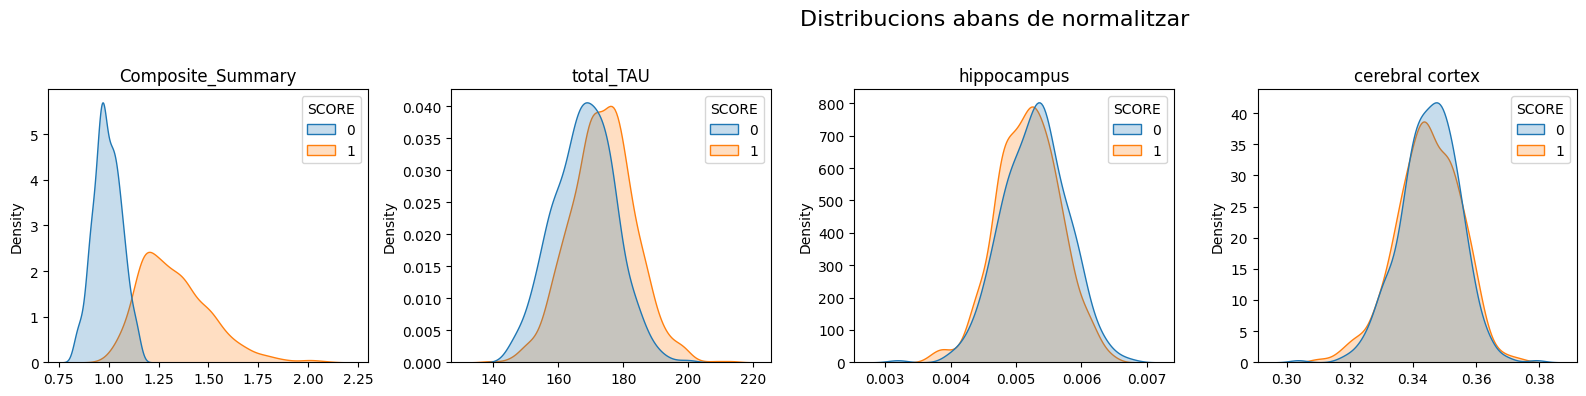

In [29]:
# first a quick look at the patient and control distribution for one of our biomarkers

# Observarem totes les distribucions en una sola quadrícula
n_cols = 5
n_rows = math.ceil(len(biomarkers) / n_cols)

# Fem la figura gran perquè es vegi bé
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4)) 
axes = axes.flatten()  # Per poder iterar fàcilment

for i, biomarker in enumerate(biomarkers):
    sns.kdeplot(
        data=data,
        x=biomarker,
        hue='SCORE',
        fill=True,  
        common_norm=False,  
        ax=axes[i]  
    )
    axes[i].set_title(biomarker, fontsize=12)
    axes[i].set_xlabel('')  

# Esborrem alguns espais que no necessitem
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribucions abans de normalitzar', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
plt.close()  # Per netejar les figures

## NORMALITZACIÓ

In [30]:
# now we perform the normalization

# make a copy of our dataframe (we don't want to overwrite our original data)
zdata = pandas.DataFrame(data,copy=True)

# for each biomarker
for biomarker in biomarkers:
    mod = smf.ols('Q("%s") ~ PTAGE + APOE_E4_COUNT'%biomarker,  # fit a model finding the effect of age and headsize on biomarker
                  data=data[data.SCORE==0] # fit this model *only* to individuals in the control group
                 ).fit() # fit model    
    #print(mod.summary())
    
    # get the "predicted" values for all subjects based on the control model parameters
    predicted = mod.predict(data[['PTAGE', 'APOE_E4_COUNT',biomarker]]) 
    
    # calculate our zscore: observed - predicted / SD of the control group residuals
    w_score = (data.loc[:,biomarker] - predicted) / mod.resid.std()
    
    #print(np.mean(w_score[data.SCORE==0]))
    #print(np.std(w_score[data.SCORE==0]))
    
    # save zscore back into our new (copied) dataframe
    zdata.loc[:,biomarker] = w_score

Observem un _scatterplot_ abans i després de normalitzar

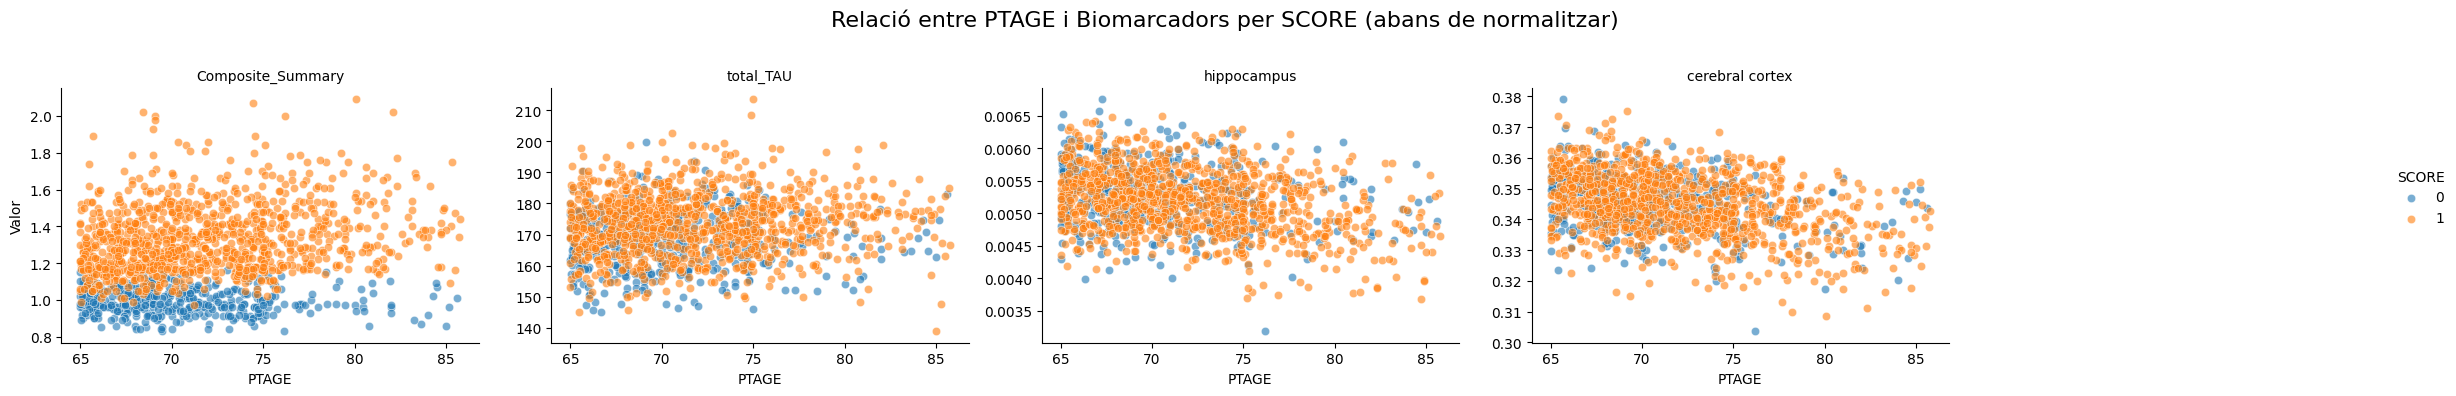

In [ ]:
# Scatterplot abans de normalitzar

# Ho mirarem pels biomarcadors
cols_to_melt = [b for b in biomarkers if b in data.columns]

# Això crea un nou DataFrame on cada fila té: PTAGE, SCORE, el nom del biomarcador i el seu valor.
data_long_age = data.melt(id_vars=['PTAGE', 'SCORE'],
                           value_vars=cols_to_melt,
                           var_name='Biomarker',
                           value_name='Value')

# Creem la quadrícula (FacetGrid)
# col="Biomarker" crea un subplot per cada biomarcador diferent.
# col_wrap=5 farà que cada 5 gràfics salti de línia.
# hue="SCORE" coloreja els punts segons el SCORE.
g = sns.FacetGrid(data_long_age, col="Biomarker", hue="SCORE",
                  col_wrap=5, sharex=True, sharey=False, height=4, aspect=1.2)

# Mapegem el scatterplot a cada quadre
# 'PTAGE' anirà a l'eix X, i 'Value' (el valor del biomarcador) a l'eix Y.
# 'sharex=True' (per defecte a true quan els eixos X són els mateixos)
# 'sharey=False' és CRUCIAL perquè els diferents biomarcadors tenen escales molt diferents.
g.map(sns.scatterplot, "PTAGE", "Value", alpha=0.6)

# Ajustos estètics i títols
g.add_legend() # Afegeix la llegenda del SCORE
g.set_titles("{col_name}") # Posa el nom del biomarcador com a títol de cada sub-gràfic
g.set_axis_labels("PTAGE", "Valor")

# Títol general per a tota la figura
plt.subplots_adjust(top=0.95) # Deixa un espai per al títol
g.fig.suptitle('Relació entre PTAGE i Biomarcadors per SCORE (abans de normalitzar)', fontsize=16)
g.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()
plt.close()

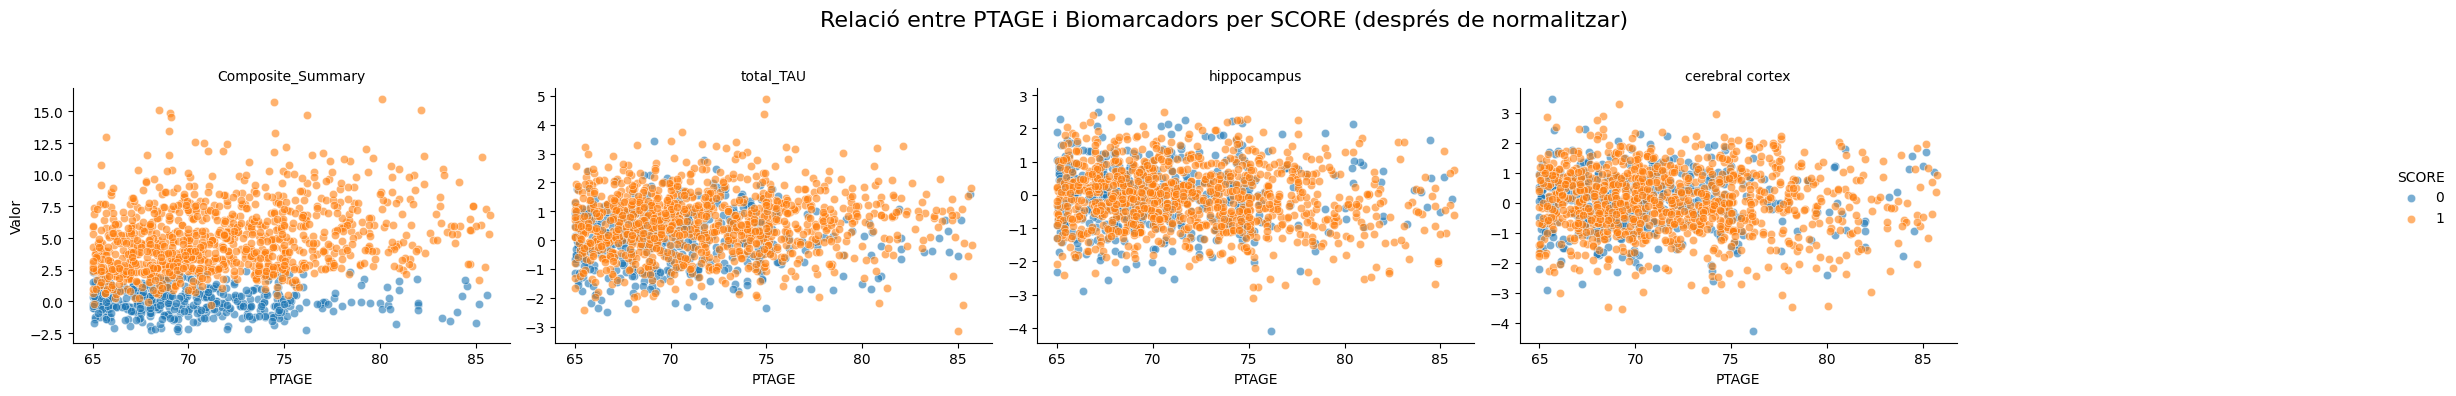

In [32]:

cols_to_melt = [b for b in biomarkers if b in zdata.columns]

zdata_long_age = zdata.melt(id_vars=['PTAGE', 'SCORE'],
                           value_vars=cols_to_melt,
                           var_name='Biomarker',
                           value_name='Value')

g = sns.FacetGrid(zdata_long_age, col="Biomarker", hue="SCORE",
                  col_wrap=5, sharex=True, sharey=False, height=4, aspect=1.2)

g.map(sns.scatterplot, "PTAGE", "Value", alpha=0.6)

g.add_legend() 
g.set_titles("{col_name}") 
g.set_axis_labels("PTAGE", "Valor")

plt.subplots_adjust(top=0.95) 
g.fig.suptitle('Relació entre PTAGE i Biomarcadors per SCORE (després de normalitzar)', fontsize=16)
g.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()
plt.close()

Podem tornar a mirar les distribucions un cop havent normalitzat

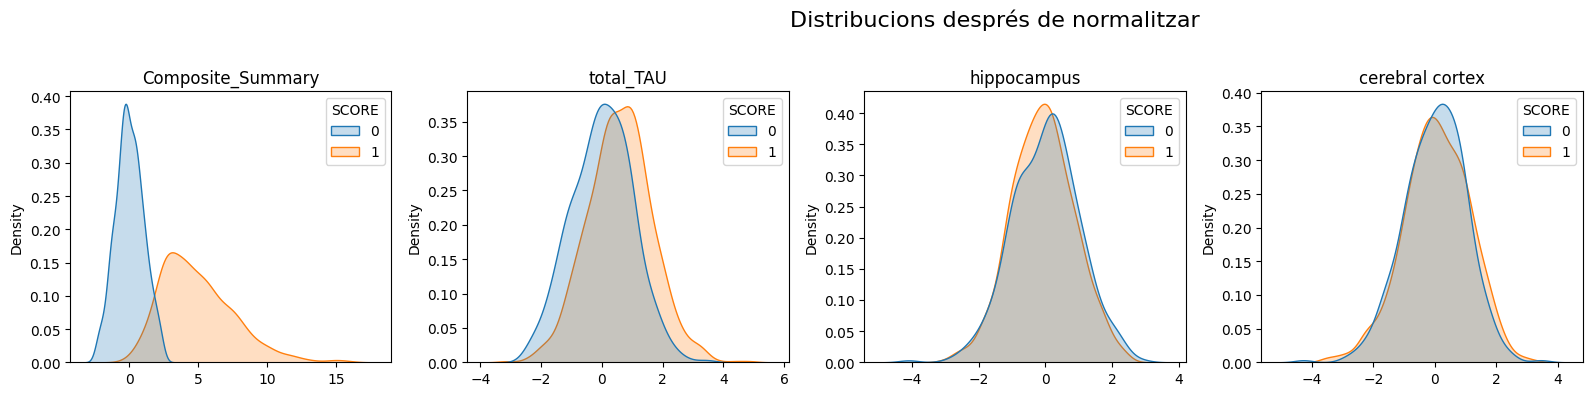

In [33]:
n_cols = 5
n_rows = math.ceil(len(biomarkers) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()  

for i, biomarker in enumerate(biomarkers):
    sns.kdeplot(
        data=zdata,
        x=biomarker,
        hue='SCORE',
        fill=True,  
        common_norm=False,  
        ax=axes[i]  
    )
    axes[i].set_title(biomarker, fontsize=12)
    axes[i].set_xlabel('')  

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribucions després de normalitzar', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
plt.close()  

## CLIPPING

In [34]:
zdata = np.clip(zdata, -5, 5)

## PREPARACIÓ DELS INPUTS DE SUSTAIN

In [35]:
# Prepare the susTAIN inputs

N = len(biomarkers)         # number of biomarkers

SuStaInLabels = biomarkers
Z_vals = np.array([[1,2,3]]*N)     # Z-scores for each biomarker
Z_max  = np.array([5]*N)  

# Input the settings for z-score SuStaIn
# To make the tutorial run faster I've set 
# N_startpoints = 10 and N_iterations_MCMC = int(1e4)
# I recommend using N_startpoints = 25 and 
# N_iterations_MCMC = int(1e5) or int(1e6) in general though

N_startpoints = 10
N_S_max = 3 # Aquí per canviar quants subtipus li posem (N_S_max = control + n_subtipus)
N_iterations_MCMC = int(1e4)
output_folder = os.path.join(os.getcwd(), 'WorkshopOutput')
dataset_name = 'WorkshopOutput'

# Initiate the SuStaIn object
sustain_input = pySuStaIn.ZscoreSustain(
                              zdata[biomarkers].values,
                              Z_vals,
                              Z_max,
                              SuStaInLabels,
                              N_startpoints,
                              N_S_max, 
                              N_iterations_MCMC, 
                              output_folder, 
                              dataset_name, 
                              False)

# EXECUTAR SUSTAIN

Aquesta següent cel·la pot trigar uns minuts a executar-se si s'esborra la carpeta `WorkshopOutput`, que conté informació de subtipus ja executats.

In [36]:
# make the output directory if it's not already created
if not os.path.isdir(output_folder):
    os.mkdir(output_folder)

samples_sequence,   \
samples_f,          \
ml_subtype,         \
prob_ml_subtype,    \
ml_stage,           \
prob_ml_stage,      \
prob_subtype_stage  = sustain_input.run_sustain_algorithm()

Failed to find pickle file: c:\Users\ASUS\Documents\Classe\Universitat\4t Carrera\TFG\SCRIPTS CORREGITS\Demos\demo SuStaIn\WorkshopOutput\pickle_files\WorkshopOutput_subtype0.pickle. Running SuStaIn model for 0 subtype.
Finding ML solution to 1 cluster problem
Overall ML likelihood is -11202.24989873099


MCMC Iteration: 100%|██████████| 10000/10000 [00:10<00:00, 936.47it/s]


Failed to find pickle file: c:\Users\ASUS\Documents\Classe\Universitat\4t Carrera\TFG\SCRIPTS CORREGITS\Demos\demo SuStaIn\WorkshopOutput\pickle_files\WorkshopOutput_subtype1.pickle. Running SuStaIn model for 1 subtype.
Splitting cluster 1 of 1
 + Resolving 2 cluster problem
 + Finding ML solution from hierarchical initialisation
- ML likelihood is [-11202.24989873]
Overall ML likelihood is [-11202.24989873]


MCMC Iteration: 100%|██████████| 10000/10000 [00:25<00:00, 393.04it/s]


Failed to find pickle file: c:\Users\ASUS\Documents\Classe\Universitat\4t Carrera\TFG\SCRIPTS CORREGITS\Demos\demo SuStaIn\WorkshopOutput\pickle_files\WorkshopOutput_subtype2.pickle. Running SuStaIn model for 2 subtype.
Splitting cluster 1 of 2
 + Resolving 2 cluster problem
 + Finding ML solution from hierarchical initialisation
- ML likelihood is [-11191.56230883]
Cluster 2 of 2 too small for subdivision
Overall ML likelihood is [-11191.56230883]


MCMC Iteration: 100%|██████████| 10000/10000 [00:34<00:00, 287.48it/s]


## EVALUACIÓ DELS SUBTIPUS

Gràfic PVD.

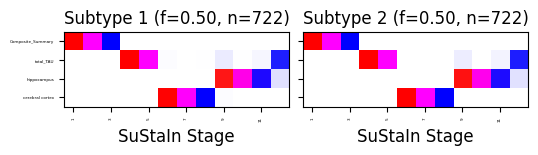

In [52]:
# Let's plot positional variance diagrams to interpret the subtype progressions

s = 1 # 1 split = 2 subtypes, 2 split = 3 subtypes
M = len(zdata) 

# get the sample sequences and f
pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
pk = pandas.read_pickle(pickle_filename_s)
samples_sequence = pk["samples_sequence"]
samples_f = pk["samples_f"]

# use this information to plot the positional variance diagrams
tmp=pySuStaIn.ZscoreSustain._plot_sustain_model(sustain_input,samples_sequence,samples_f,M,subtype_order=(0,1), biomarker_labels=biomarkers)

for axis in plt.gcf().axes:
    axis.tick_params(axis='x', rotation=90, labelsize=3)
    axis.tick_params(axis='y', labelsize=3)
    
    # No mostrem tots els números de l'eix X per no saturar
    ticks = axis.get_xticks()
    axis.set_xticks(ticks[::2]) # Ensenyem un de cada dos nombres

In [53]:
# Subtype and stage individuals

# let's take a look at all of the things that exist in SuStaIn's output (pickle) file
print(pk.keys())

# Ens afegeix columnes al nostre df:
#   - El subtipus assignat
#   - La certesa (probabilitat) que té el model de que pertany a aquest subtipus
#   - L'etapa de la malaltia (stage)
#   - La certesa de que aquest pacient estigui en aquesta etapa

# Aquí per el cas dos subtipus
s = 1
pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
pk = pandas.read_pickle(pickle_filename_s)

for variable in ['ml_subtype', # the assigned subtype
                 'prob_ml_subtype', # the probability of the assigned subtype
                 'ml_stage', # the assigned stage 
                 'prob_ml_stage',]: # the probability of the assigned stage
    
    # add SuStaIn output to dataframe
    zdata.loc[:,variable] = pk[variable] 

# let's also add the probability for each subject of being each subtype
for i in range(s):
    zdata.loc[:,'prob_S%s'%i] = pk['prob_subtype'][:,i]

print(zdata.head())

dict_keys(['samples_sequence', 'samples_f', 'samples_likelihood', 'ml_subtype', 'prob_ml_subtype', 'ml_stage', 'prob_ml_stage', 'prob_subtype', 'prob_stage', 'prob_subtype_stage', 'ml_sequence_EM', 'ml_sequence_prev_EM', 'ml_f_EM', 'ml_f_prev_EM'])
   SCORE  PTAGE  APOE_E4_COUNT  Composite_Summary  total_TAU  hippocampus  \
0      1    5.0            0.0           2.627226   0.832814     2.350639   
1      1    5.0            1.0           2.908715   0.049934    -0.295593   
2      0    5.0            0.0           1.745031   0.743281    -1.104758   
3      0    5.0            0.0           0.204653   0.898226    -0.671661   
4      0    5.0            0.0           0.102815  -0.171363     0.226977   

   cerebral cortex  ml_subtype  prob_ml_subtype  ml_stage  prob_ml_stage  \
0        -0.717837         0.0         0.500264       2.0       0.142038   
1         1.286948         0.0         0.500215       2.0       0.159773   
2        -1.227270         1.0         0.500289       1.0   

Establim el subtipus 0 com a control.

In [54]:
# IMPORTANT!!! The last thing we need to do is to set all "Stage 0" subtypes to their own subtype
# We'll set current subtype (0 and 1) to 1 and 0, and we'll call "Stage 0" individuals subtype 0.

# make current subtypes (0 and 1) 1 and 2 instead
zdata.loc[:,'ml_subtype'] = zdata.ml_subtype.values + 1

# convert "Stage 0" subjects to subtype 0
zdata.loc[zdata.ml_stage==0,'ml_subtype'] = 0

print(zdata.ml_subtype.value_counts())

ml_subtype
2.0    555
1.0    497
0.0    393
Name: count, dtype: int64


Podem mirar ara un histograma que ens mostri els SCORE (positiu o negatiu) que hi ha a cada subtipus.

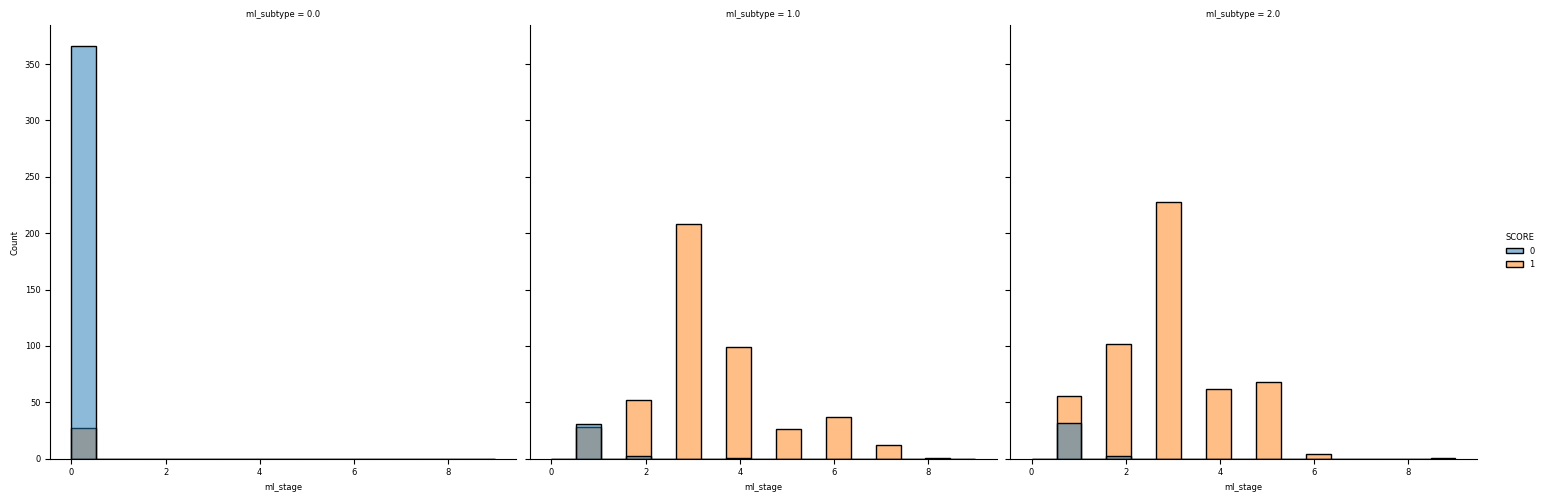

<Figure size 640x480 with 0 Axes>

In [55]:
#Ens serveix per comprovar si els individus control han estat assignats al subtipus 0

sns.displot(x='ml_stage',hue='SCORE',data=zdata,col='ml_subtype')
plt.show()
plt.clf() 

També ho podem fer amb uns quants prints.

In [56]:
# Recorrem tots els subtipus
for subtype in sorted(zdata['ml_subtype'].unique()):
    # Filtrem el dataframe pel subtipus i en mirem l'SCORE
    scores_subtipo = zdata.loc[zdata['ml_subtype'] == subtype, 'SCORE'].values
    conteo = zdata.loc[zdata['ml_subtype'] == subtype, 'SCORE'].value_counts()
    
    print(f"\n--- Subtipus {subtype} ---")
    print(f"Quantitat de subjectes: {len(scores_subtipo)}")
    print(f"Valors de SCORE: {conteo}")


--- Subtipus 0.0 ---
Quantitat de subjectes: 393
Valors de SCORE: SCORE
0    366
1     27
Name: count, dtype: int64

--- Subtipus 1.0 ---
Quantitat de subjectes: 497
Valors de SCORE: SCORE
1    463
0     34
Name: count, dtype: int64

--- Subtipus 2.0 ---
Quantitat de subjectes: 555
Valors de SCORE: SCORE
1    521
0     34
Name: count, dtype: int64
